In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ru-bridge-telegram/zarussia_1_green_df.csv
/kaggle/input/ru-bridge-telegram/Lunay14_green_df.csv
/kaggle/input/ru-bridge-telegram/ua_tribunal_red_df.csv
/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv
/kaggle/input/ru-bridge-telegram/domain_pc1.csv
/kaggle/input/ru-bridge-telegram/rtdru_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/orchestra_w_green_df.csv
/kaggle/input/ru-bridge-telegram/Bridge_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/Seed_Channels_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/rustroyka1945_green_df.csv
/kaggle/input/ru-bridge-telegram/novosti_efir_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/warfakebelgorod_green_df.csv
/kaggle/input/ru-bridge-telegram/msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/CyberfrontZ_msg_csv_urls_only.csv
/kaggle/input/ru-bridge-telegram/heroesofZ_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/voin_dv_green_df.csv


In [2]:
bridge_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv", low_memory=False)
seed_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/msgs_dataset.csv", low_memory=False)
domain_rating_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/domain_pc1.csv", low_memory=False)

combined_df = pd.concat([seed_df, bridge_df], ignore_index=True)

excluded_domains = []

In [3]:
columns_to_keep = [
    'channel_name', 'msg_id', 'message', 'cleaned_message', 'date', 
    'msg_link', 'has_url', 'url', 'domain', 'url_title', 'url_description'
]

# Select only the columns to keep
combined_filtered_df = combined_df[columns_to_keep]
combined_filtered_df = combined_filtered_df[combined_filtered_df['has_url'] == 1 & ~combined_filtered_df['domain'].isin(excluded_domains)]

In [4]:
combined_filtered_df = combined_filtered_df.merge(domain_rating_df, on='domain', how='inner')
filtered_df_sorted = combined_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1 = filtered_df_sorted['pc1'].mean()

# print("Filtered and Sorted DataFrame:")
# print(filtered_df_sorted[['domain', 'pc1', 'channel_name', 'msg_id', 'msg_link']])

print("\nAverage PC1 Score of full network:", average_pc1)


Average PC1 Score of full network: 0.4673981770307969


In [5]:
domain_frequencies = filtered_df_sorted['domain'].value_counts()
domain_frequencies

domain
youtube.com                3221
ria.ru                      330
facebook.com                 97
nytimes.com                  89
n-tv.de                      64
                           ... 
juedische-allgemeine.de       1
mopo.de                       1
ndtv.com                      1
presseportal.de               1
lejsl.com                     1
Name: count, Length: 289, dtype: int64

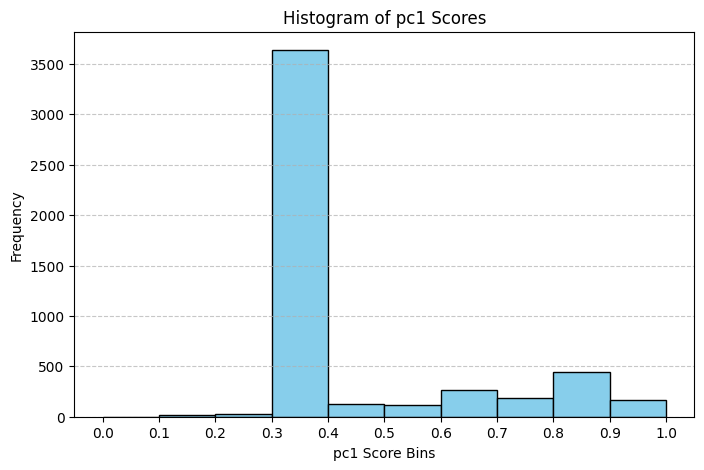

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
top_bridge_channels = ['warfakebelgorod', 'zarussia_1', 'ua_tribunal']
top_bridge_excluded_df = bridge_df[~bridge_df['channel_name'].isin(top_bridge_channels)]

In [8]:
subnetwork_df = pd.concat([seed_df, top_bridge_excluded_df], ignore_index=True)

columns_to_keep = [
    'channel_name', 'msg_id', 'message', 'cleaned_message', 'date', 
    'msg_link', 'has_url', 'url', 'domain', 'url_title', 'url_description'
]

# Select only the columns to keep
subnetwork_filtered_df = subnetwork_df[columns_to_keep]

subnetwork_filtered_df = subnetwork_filtered_df[subnetwork_filtered_df['has_url'] == 1 & ~subnetwork_filtered_df['domain'].isin(excluded_domains)]

In [9]:
subnetwork_filtered_df = subnetwork_filtered_df.merge(domain_rating_df, on='domain', how='inner')
subnetwork_filtered_df_sorted = subnetwork_filtered_df.sort_values(by='pc1', ascending=False)

average_pc1_subnetwork = subnetwork_filtered_df_sorted['pc1'].mean()

# print("Filtered and Sorted DataFrame:")
# print(filtered_df_sorted[['domain', 'pc1', 'channel_name', 'msg_id', 'msg_link']])

print("\nAverage PC1 Score of sub-network:", average_pc1_subnetwork)


Average PC1 Score of sub-network: 0.46701701773872867


In [10]:
domain_frequencies_subnetwork = subnetwork_filtered_df_sorted['domain'].value_counts()
domain_frequencies_subnetwork

domain
youtube.com             3218
ria.ru                   329
facebook.com              97
nytimes.com               89
n-tv.de                   64
                        ... 
sltrib.com                 1
sciencedirect.com          1
popularmechanics.com       1
defenseone.com             1
nzherald.co.nz             1
Name: count, Length: 289, dtype: int64

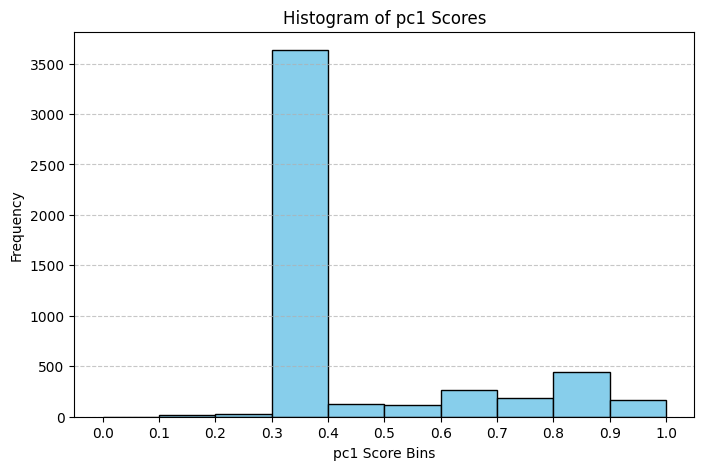

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(subnetwork_filtered_df_sorted["pc1"], bins=10, range=(0, 1), edgecolor='black', color='skyblue')
plt.title("Histogram of pc1 Scores")
plt.xlabel("pc1 Score Bins")
plt.ylabel("Frequency")
plt.xticks([i/10 for i in range(11)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
percent_difference = abs(average_pc1_subnetwork - average_pc1) / ((average_pc1_subnetwork + average_pc1) / 2) * 100

print(percent_difference)

0.08158242592838745


In [13]:
!pip install torch transformers

In [ ]:
from transformers import pipeline
import torch
import time

def get_device():
    if torch.cuda.is_available():
        return 0  # Use CUDA (GPU)
    elif torch.backends.mps.is_available():
        return "mps"  # Use Apple Silicon GPU
    else:
        return -1  # Use CPU


class SentimentAnalyser:
    model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
    device = get_device()
    pipeline = pipeline('sentiment-analysis', model=model_name, tokenizer=model_name, device=device)

    @staticmethod
    def predict(text: list | str):
        results = SentimentAnalyser.pipeline(text)
        return results


class EmotionAnalyser:
    model_name = "bhadresh-savani/distilbert-base-uncased-emotion"
    device = get_device()
    pipeline = pipeline('text-classification', model=model_name, tokenizer=model_name, device=device)

    @staticmethod
    def predict(text: list | str):
        results = EmotionAnalyser.pipeline(text)
        return results


class ToxicityAnalyser:
    model_name = "unitary/toxic-bert"
    device = get_device()
    pipeline = pipeline("text-classification", model=model_name, device=device, top_k=5)

    @staticmethod
    def predict(text: list | str):
        result = ToxicityAnalyser.pipeline(text)
        return result

sentiment_pipeline = SentimentAnalyser()
toxicity_pipeline = ToxicityAnalyser()    
emotion_pipeline = EmotionAnalyser()

def analyse_sentiment(text: str | list) -> dict:
    result = sentiment_pipeline.predict(text)
    return result

def analyse_toxicity(text: str | list) -> dict:
    result = toxicity_pipeline.predict(text)
    return result

def analyse_emotion(text: str | list) -> dict:
    result = emotion_pipeline.predict(text)
    return result

def assign_toxicity_label(preds, threshold=0.1, difference_threshold=0.1):
    sorted_preds = sorted(preds, key=lambda x: x['score'], reverse=True)
    max_label, max_score = sorted_preds[0]['label'], sorted_preds[0]['score']

    if max_score < threshold:
        return 'non_toxic'

    second_label, second_score = sorted_preds[1]['label'], sorted_preds[1]['score']
    if (max_score - second_score) < difference_threshold:
        return second_label

    return max_label

In [15]:
print(len(seed_df), len(bridge_df), len(seed_df)+len(bridge_df))

922701 168820 1091521


In [16]:
start= time.time()
combined_df2 = bridge_df
combined_df2 = combined_df2.dropna(subset=['cleaned_message'])
combined_df2['cleaned_message'] = combined_df2['cleaned_message'].apply(lambda x: x[:512])

combined_df2['sentiment'] = analyse_sentiment(combined_df2['cleaned_message'].tolist())
combined_df2['emotion'] = analyse_emotion(combined_df2['cleaned_message'].tolist())
combined_df2['toxicity'] = analyse_toxicity(combined_df2['cleaned_message'].tolist())

combined_df2['sentiment'] = combined_df2['sentiment'].apply(lambda x: x['label'])
combined_df2['emotion'] = combined_df2['emotion'].apply(lambda x: x['label'])
combined_df2['toxicity'] = combined_df2['toxicity'].apply(assign_toxicity_label)
end= time.time()

<ipython-input-16-d04ee5d254ec>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df2['cleaned_message'] = combined_df2['cleaned_message'].apply(lambda x: x[:512])
<ipython-input-16-d04ee5d254ec>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df2['sentiment'] = analyse_sentiment(combined_df2['cleaned_message'].tolist())
<ipython-input-16-d04ee5d254ec>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [17]:
end-start

3899.3845133781433

In [18]:
emotion_distribution = combined_df2.groupby(['emotion'])['emotion'].count().reset_index(name='posts')
sentiment_distribution = combined_df2.groupby(['sentiment'])['sentiment'].count().reset_index(name='posts')
toxicity_distribution = combined_df2.groupby(['toxicity'])['toxicity'].count().reset_index(name='posts')

print(emotion_distribution.to_dict(orient='records'))
print(sentiment_distribution.to_dict(orient='records'))
print(toxicity_distribution.to_dict(orient='records'))

[{'emotion': 'anger', 'posts': 3728}, {'emotion': 'fear', 'posts': 69}, {'emotion': 'joy', 'posts': 119564}, {'emotion': 'love', 'posts': 1}, {'emotion': 'sadness', 'posts': 11}, {'emotion': 'surprise', 'posts': 1}]
[{'sentiment': 'negative', 'posts': 39534}, {'sentiment': 'neutral', 'posts': 67895}, {'sentiment': 'positive', 'posts': 15945}]
[{'toxicity': 'non_toxic', 'posts': 123324}, {'toxicity': 'obscene', 'posts': 28}, {'toxicity': 'toxic', 'posts': 22}]


In [19]:
combined_df2.to_csv('bridge_messages_with_sentiment_emotion_toxicity.csv', index=False)

<a href="bridge_messages_with_sentiment_emotion_toxicity.csv"> Download File </a>

In [20]:
# combined_df1 = combined_df
# combined_df1 = combined_df1.dropna(subset=['cleaned_message'])
# # combined_df1['cleaned_message'] = combined_df1['cleaned_message'].astype(str)
# combined_df1['cleaned_message'] = combined_df1['cleaned_message'].apply(lambda x: x[:512])
# # sentiment_time = time.time()
# # combined_df1['sentiment'] = analyse_sentiment(combined_df1['cleaned_message'].tolist())
# # combined_df1['sentiment'] = combined_df1['sentiment'].apply(lambda x: x['label'])
# # print("sentiment time: %.2f seconds", time.time() - sentiment_time)

# subnetwork_df1 = subnetwork_df
# subnetwork_df1 = subnetwork_df1.dropna(subset=['cleaned_message'])
# # subnetwork_df1['cleaned_message'] = subnetwork_df1['cleaned_message'].astype(str)
# subnetwork_df1['cleaned_message'] = subnetwork_df1['cleaned_message'].apply(lambda x: x[:512])
# # sentiment_time = time.time()
# # subnetwork_df1['sentiment'] = analyse_sentiment(subnetwork_df1['cleaned_message'].tolist())
# # subnetwork_df1['sentiment'] = subnetwork_df1['sentiment'].apply(lambda x: x['label'])
# # print("sentiment time: %.2f seconds", time.time() - sentiment_time)

# seed_df1 = seed_df
# seed_df1 = seed_df1.dropna(subset=['cleaned_message'])
# # seed_df1['cleaned_message'] = seed_df1['cleaned_message'].astype(str)
# seed_df1['cleaned_message'] = seed_df1['cleaned_message'].apply(lambda x: x[:512])
# # sentiment_time = time.time()
# # seed_df1['sentiment'] = analyse_sentiment(seed_df1['cleaned_message'].tolist())
# # seed_df1['sentiment'] = seed_df1['sentiment'].apply(lambda x: x['label'])
# # print("sentiment time: %.2f seconds", time.time() - sentiment_time)

# # sentiment_distribution = combined_df1.groupby(['sentiment'])['sentiment'].count().reset_index(name='posts')
# # subnetwork_sentiment_distribution = subnetwork_df1.groupby(['sentiment'])['sentiment'].count().reset_index(name='posts')
# # seed_sentiment_distribution = seed_df1.groupby(['sentiment'])['sentiment'].count().reset_index(name='posts')

In [21]:
# print(sentiment_distribution.to_dict(orient='records'))
# print(subnetwork_sentiment_distribution.to_dict(orient='records'))
# print(seed_sentiment_distribution.to_dict(orient='records'))

In [22]:
# # combined_df2 = combined_df
# # combined_df2 = combined_df2.dropna(subset=['cleaned_message'])
# # combined_df2['cleaned_message'] = combined_df2['cleaned_message'].apply(lambda x: x[:512])
# emotion_time = time.time()
# combined_df1['emotion'] = analyse_emotion(combined_df1['cleaned_message'].tolist())
# combined_df1['emotion'] = combined_df1['emotion'].apply(lambda x: x['label'])
# print("emotion time: %.2f seconds", time.time() - emotion_time)

# # subnetwork_df2 = subnetwork_df
# # subnetwork_df2 = subnetwork_df2.dropna(subset=['cleaned_message'])
# # subnetwork_df2['cleaned_message'] = subnetwork_df2['cleaned_message'].apply(lambda x: x[:512])
# emotion_time = time.time()
# subnetwork_df1['emotion'] = analyse_emotion(subnetwork_df1['cleaned_message'].tolist())
# subnetwork_df1['emotion'] = subnetwork_df1['emotion'].apply(lambda x: x['label'])
# print("emotion time: %.2f seconds", time.time() - emotion_time)

# # seed_df2 = seed_df
# # seed_df2 = seed_df2.dropna(subset=['cleaned_message'])
# # seed_df2['cleaned_message'] = seed_df2['cleaned_message'].apply(lambda x: x[:512])
# emotion_time = time.time()
# seed_df1['emotion'] = analyse_emotion(seed_df1['cleaned_message'].tolist())
# seed_df1['emotion'] = seed_df1['emotion'].apply(lambda x: x['label'])
# print("emotion time: %.2f seconds", time.time() - emotion_time)

# emotion_distribution = combined_df1.groupby(['emotion'])['emotion'].count().reset_index(name='posts')
# subnetwork_emotion_distribution = subnetwork_df1.groupby(['emotion'])['emotion'].count().reset_index(name='posts')
# seed_emotion_distribution = seed_df1.groupby(['emotion'])['emotion'].count().reset_index(name='posts')

In [23]:
# print(emotion_distribution.to_dict(orient='records'))
# print(subnetwork_emotion_distribution.to_dict(orient='records'))
# print(seed_emotion_distribution.to_dict(orient='records'))

In [24]:
# # combined_df3 = combined_df
# # combined_df3 = combined_df3.dropna(subset=['cleaned_message'])
# # combined_df3['cleaned_message'] = combined_df3['cleaned_message'].apply(lambda x: x[:512])
# toxicity_time = time.time()
# combined_df1['toxicity'] = analyse_toxicity(combined_df1['cleaned_message'].tolist())
# combined_df1['toxicity'] = combined_df1['toxicity'].apply(assign_toxicity_label)
# print("toxicity time: %.2f seconds", time.time() - toxicity_time)

# # subnetwork_df3 = subnetwork_df
# # subnetwork_df3 = subnetwork_df3.dropna(subset=['cleaned_message'])
# # subnetwork_df3['cleaned_message'] = subnetwork_df3['cleaned_message'].apply(lambda x: x[:512])
# toxicity_time = time.time()
# subnetwork_df1['toxicity'] = analyse_toxicity(subnetwork_df1['cleaned_message'].tolist())
# subnetwork_df1['toxicity'] = subnetwork_df1['toxicity'].apply(assign_toxicity_label)
# print("toxicity time: %.2f seconds", time.time() - toxicity_time)

# # seed_df3 = seed_df
# # seed_df3 = seed_df3.dropna(subset=['cleaned_message'])
# # seed_df3['cleaned_message'] = seed_df3['cleaned_message'].apply(lambda x: x[:512])
# emotion_time = time.time()
# seed_df1['toxicity'] = analyse_toxicity(seed_df1['cleaned_message'].tolist())
# seed_df1['toxicity'] = seed_df1['toxicity'].apply(assign_toxicity_label)
# print("toxicity time: %.2f seconds", time.time() - toxicity_time)

# toxicity_distribution = combined_df1.groupby(['toxicity'])['toxicity'].count().reset_index(name='posts')
# subnetwork_toxicity_distribution = subnetwork_df1.groupby(['toxicity'])['toxicity'].count().reset_index(name='posts')
# seed_toxicity_distribution = seed_df1.groupby(['toxicity'])['toxicity'].count().reset_index(name='posts')

In [25]:
# print(toxicity_distribution.to_dict(orient='records'))
# print(subnetwork_toxicity_distribution.to_dict(orient='records'))
# print(seed_toxicity_distribution.to_dict(orient='records'))